# Case problem


Care Bank ran a campaign for term-deposit subscription last year for its existing customers that showed a healthy conversion rate of over 12%. The bank is interested in a term deposit subscription because it gets good returns from a term deposit than a savings account as the customer is deprived of the rights to access the money prior to the maturity unless the customer is ready to compensate the bank. Banks can use that money to invest in other markets for better returns.

Now, the bank is planning to launch a new campaign again but this time it wants to utilize data available from previous campaigns and also to automate this process with better target marketing to increase the success ratio with a minimal budget.

You, as a Data scientist at Care bank, have to build a model that will help the marketing department, in next campaign, to identify the customers who have a higher probability of subscribing to the term deposit. This will increase the success ratio while at the same time reduce the cost of the campaign.

## Data dictionary

**Bank client data**
* age 
* job : type of job 
* marital : marital status
* education 
* default: has credit in default? 
* housing: has housing loan? 
* loan: has personal loan?
* balance: balance in account
* contact: contact communication type

**Related to this campaign**
* month: last contact month of the year
* day_of_week: last contact day of the week
* duration: last contact duration, in seconds*
* campaign: number of contacts performed during this campaign and for this client

**Related to previous campaign**
* pdays: number of days that passed by after the client was last contacted from a previous campaign
* previous: number of contacts performed before this campaign and for this client
* poutcome: outcome of the previous marketing campaign

**Output variable (desired target): has the client subscribed to a term deposit?**

In [1]:
## our desired libraries

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_theme()

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

In [2]:
bank_data = pd.read_csv("bank-full.csv")
bank_data.sample(7)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
7452,56,services,married,secondary,no,705,yes,no,unknown,29,may,151,2,-1,0,unknown,no
39475,28,technician,single,tertiary,no,0,yes,no,cellular,25,may,269,1,40,2,failure,yes
18974,60,entrepreneur,married,unknown,yes,-284,yes,yes,cellular,4,aug,67,8,-1,0,unknown,no
20633,39,management,married,tertiary,no,271,yes,no,cellular,12,aug,1344,1,-1,0,unknown,yes
18277,41,technician,single,secondary,no,3023,no,no,cellular,31,jul,616,3,-1,0,unknown,no
44960,58,admin.,divorced,secondary,no,3337,yes,no,telephone,8,oct,369,2,690,3,failure,yes
41465,52,technician,married,secondary,no,0,yes,no,cellular,7,sep,211,1,294,1,failure,yes


In [3]:
#let us make a copy of the orignal dataset
data = bank_data.copy()

In [4]:
data.info() # looks like we do not have any missing values here
# object type datatypes can be converted to category, as it reduces the data space required to store data frame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  Target     45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Let us look at some null values

In [5]:
data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
Target       0
dtype: int64

In [6]:
data.drop(['default'],axis=1,inplace=True)

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


**OBSERVATION**

- Age : it has a wide range from 18 to 95 years, mean and median are close to each other
- balance : this needs to explored a bit more as the range is from -8019 to 102127 which indicates possible outliers and need to be processed
- day: looks good 
- duration : last contact durations have extreme values 0 to 4918 , it would be worth checking if more the duration more chances of subscription
- campaign - 75% customers were contatcted thrice but the max here is 63, possible outlier
- pdays - (-1), is a suspicoius value and seems they were not conncated previously
- previous - has a lot of 0 values , which means 75% customers were not contacted previously

In [8]:
obj_cols = data.select_dtypes(['object'])
obj_cols.columns

Index(['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month',
       'poutcome', 'Target'],
      dtype='object')

In [9]:
for i in obj_cols:
    data[i] = data[i].astype('category')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   balance    45211 non-null  int64   
 5   housing    45211 non-null  category
 6   loan       45211 non-null  category
 7   contact    45211 non-null  category
 8   day        45211 non-null  int64   
 9   month      45211 non-null  category
 10  duration   45211 non-null  int64   
 11  campaign   45211 non-null  int64   
 12  pdays      45211 non-null  int64   
 13  previous   45211 non-null  int64   
 14  poutcome   45211 non-null  category
 15  Target     45211 non-null  category
dtypes: category(9), int64(7)
memory usage: 2.8 MB


#### Clearly the space usage went down from 5.9+ mb to 2.8 mb

In [11]:
#let us work on the pdays columns where value is -1
data.loc[data['pdays']==-1, "previous"].value_counts()

# assumption of -1 says that the customer was never contacted before

0    36954
Name: previous, dtype: int64

In [12]:
#let us have a look at categorical values

for i in obj_cols:
    print ("Unique values in ", i, "are:")
    print (obj_cols[i].value_counts())
    print ("***********"*10)

Unique values in  job are:
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: job, dtype: int64
**************************************************************************************************************
Unique values in  marital are:
married     27214
single      12790
divorced     5207
Name: marital, dtype: int64
**************************************************************************************************************
Unique values in  education are:
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: education, dtype: int64
**************************************************************************************************************
Unique values in  housing are:
yes    25130
no     20081
Name: housing, dtype: int64
***************

Columns like - 

a) jobs and education have 'unknown' values which can be treated like missing values.

b) cellular and poutcome have 'unknown' values but the percentage of such values is very high (81% in poutcomes and 28% in cellular) we should treat 'unknown' as a separate category for these columns.

### Univaritate analysis

In [13]:
# While doing uni-variate analysis of numerical variables we want to study their central tendency 
# and dispersion.
# Let us write a function that will help us create boxplot and histogram for any input numerical 
# variable.
# This function takes the numerical column as the input and returns the boxplots 
# and histograms for the variable.
# Let us see if this help us write faster and cleaner code.
def histogram_boxplot(feature, figsize=(15,10), bins = None):
    """ Boxplot and histogram combined
    feature: 1-d feature array
    figsize: size of fig (default (9,8))
    bins: number of bins (default None / auto)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(nrows = 2, # Number of rows of the subplot grid= 2
                                           sharex = True, # x-axis will be shared among all subplots
                                           gridspec_kw = {"height_ratios": (.25, .75)}, 
                                           figsize = figsize 
                                           ) # creating the 2 subplots
    sns.boxplot(feature, ax=ax_box2, showmeans=True, color='violet') # boxplot will be created and a star will indicate the mean value of the column
    sns.distplot(feature, kde=F, ax=ax_hist2, bins=bins,color = 'orange') if bins else sns.distplot(feature, kde=False, ax=ax_hist2,color='tab:cyan') # For histogram
    ax_hist2.axvline(np.mean(feature), color='purple', linestyle='--') # Add mean to the histogram
    ax_hist2.axvline(np.median(feature), color='black', linestyle='-') # Add median to the histogram

### Observation on Age

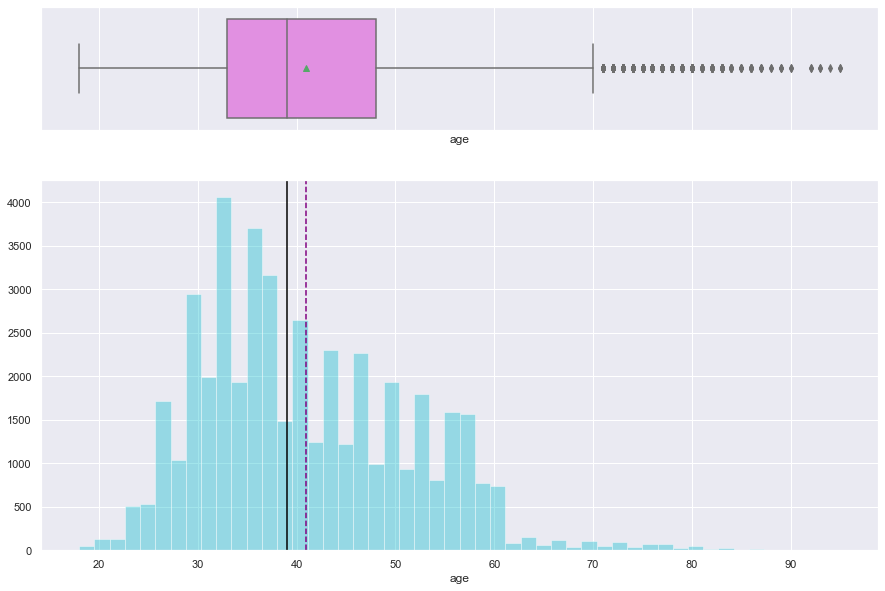

In [14]:
histogram_boxplot(data['age'])

#### The distribution is right skewed.
- People above the age of 60 would be interesting to analysis, if they are subscribing or not, if not we can treat them as outliers

### Observation on balance

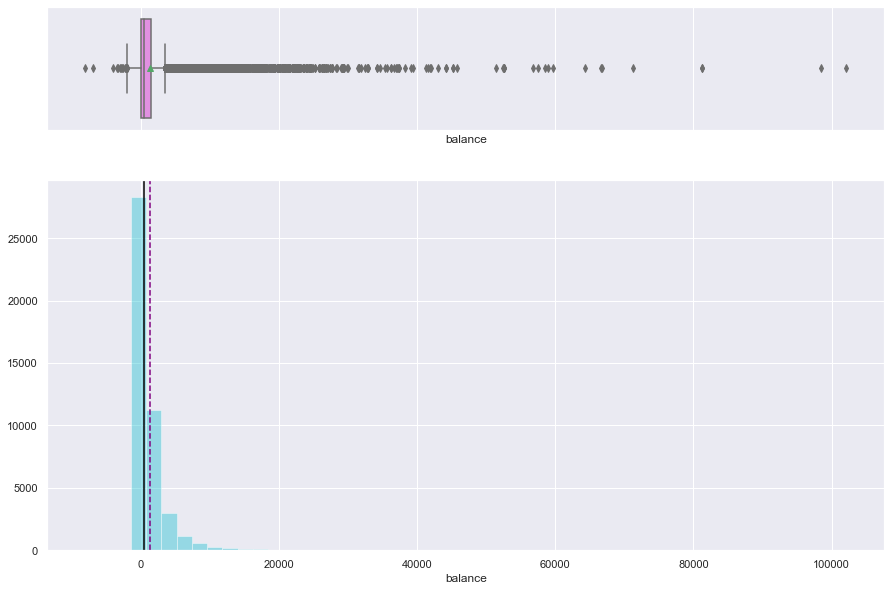

In [15]:
histogram_boxplot(data['balance'])

#### Balance can be real world scenario, where we can see a lot of differnece in balance, as visible from the box plot above as a range

### Observation on duration

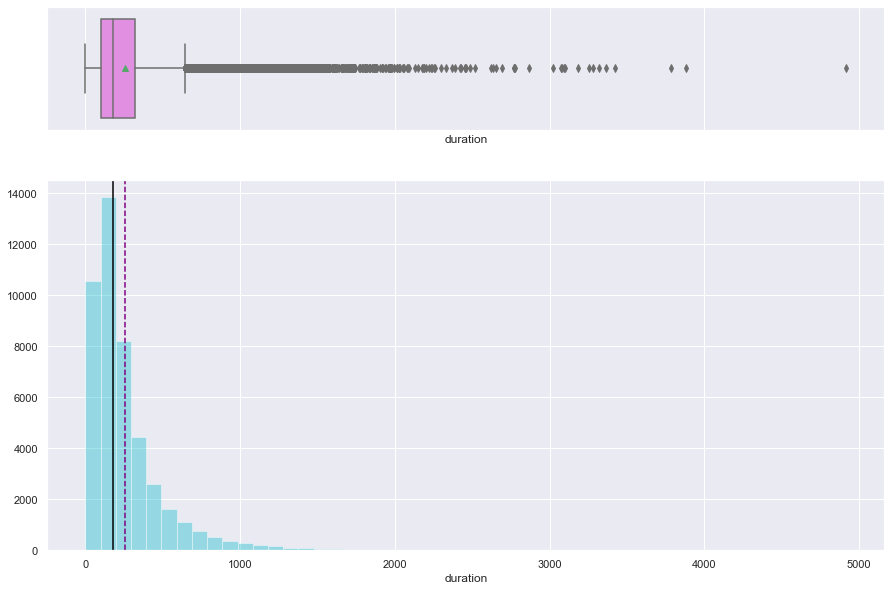

In [16]:
histogram_boxplot(data['duration'])

##### Distribution indicates the call durations are relatively shorter

In [17]:
# Function to create barplots that indicate percentage for each category.

def perc_on_bar(z):
    '''
    plot
    feature: categorical feature
    the function won't work if a column is passed in hue parameter
    '''

    total = len(data[z]) # length of the column
    plt.figure(figsize=(15,5))
    ax = sns.countplot(data[z],palette='Paired')
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total) # percentage of each class of the category
        x = p.get_x() + p.get_width() / 2 - 0.05 # width of the plot
        y = p.get_y() + p.get_height()           # hieght of the plot
        
        ax.annotate(percentage, (x, y), size = 12) # annotate the percantage 
    
    plt.show() # show the plot

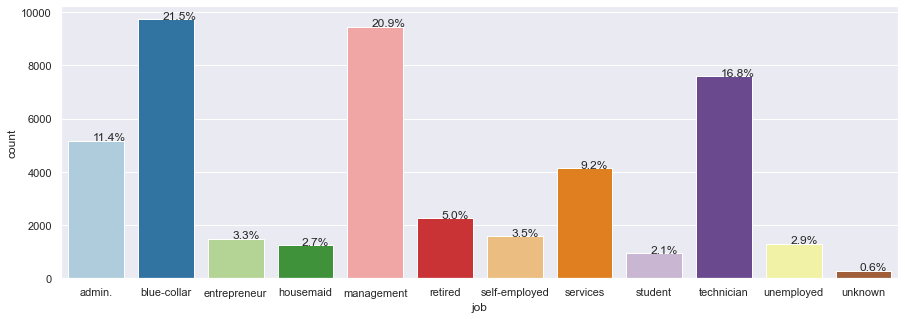

In [18]:
perc_on_bar("job")

#### Unknown jobs need to be treated, binning can be looked at in this case

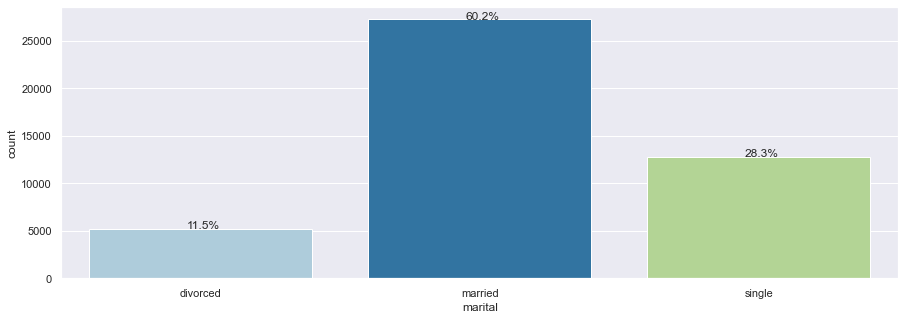

In [19]:
perc_on_bar("marital")

#### 60% of the people are married, even single and divorced can be binned in one

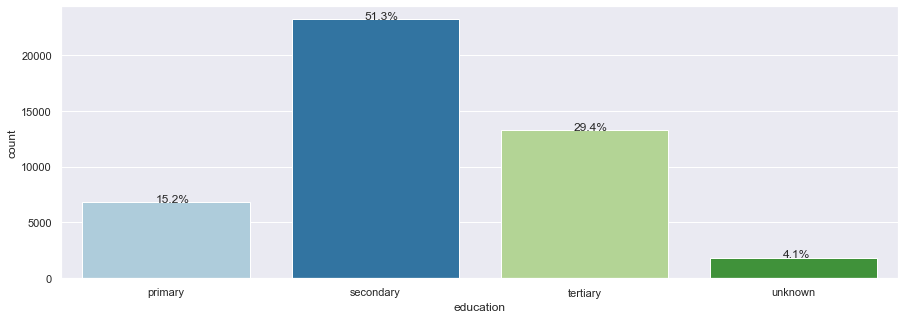

In [20]:
perc_on_bar('education')

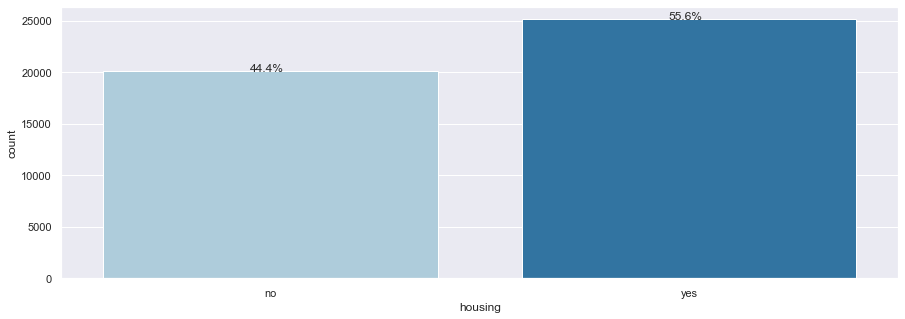

In [21]:
perc_on_bar('housing')

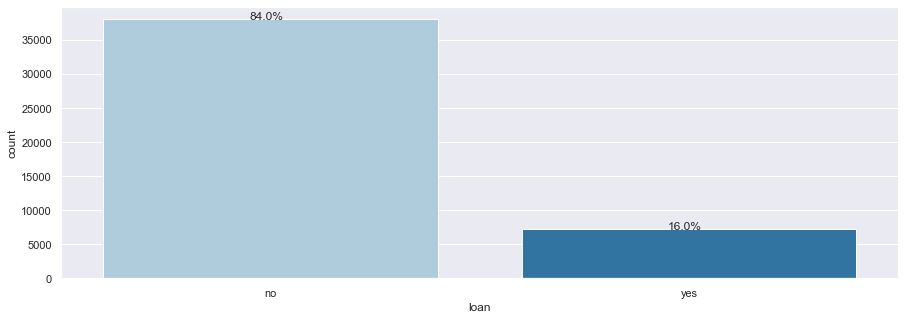

In [22]:
perc_on_bar('loan')

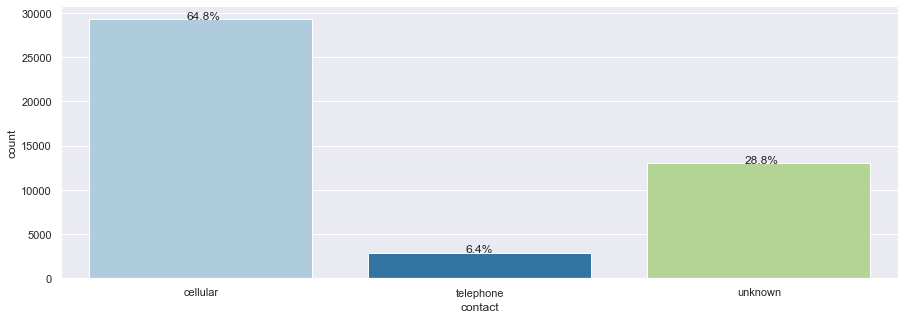

In [23]:
perc_on_bar('contact')

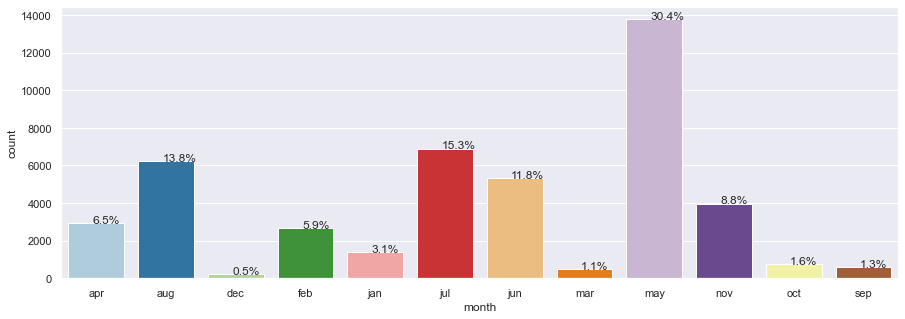

In [24]:
perc_on_bar('month')

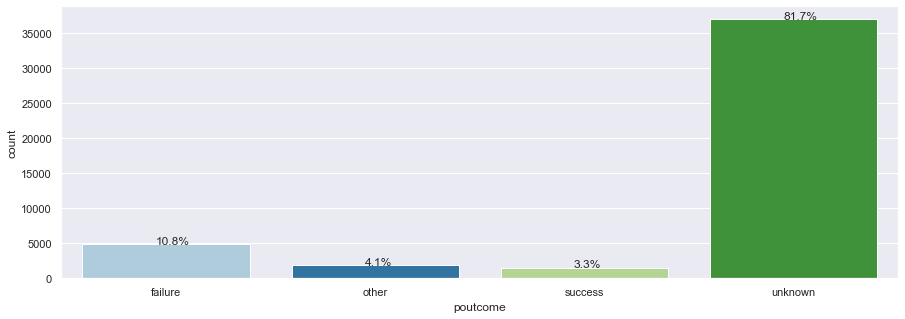

In [25]:
perc_on_bar('poutcome')

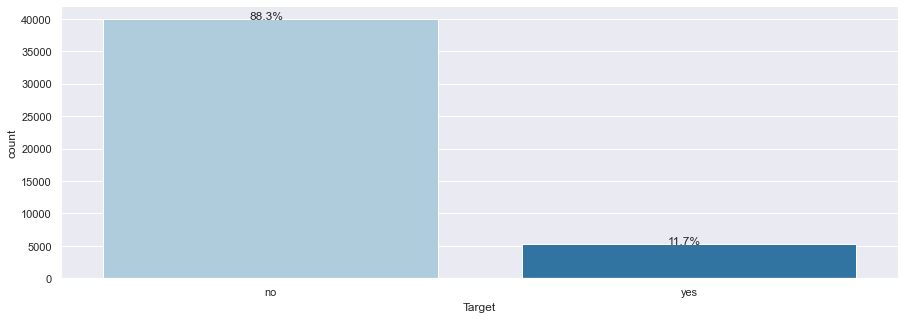

In [26]:
perc_on_bar("Target")

#### The target variable is clearly imbalacned where 88% have not subscribed

## Bivaritate analysis

<AxesSubplot:>

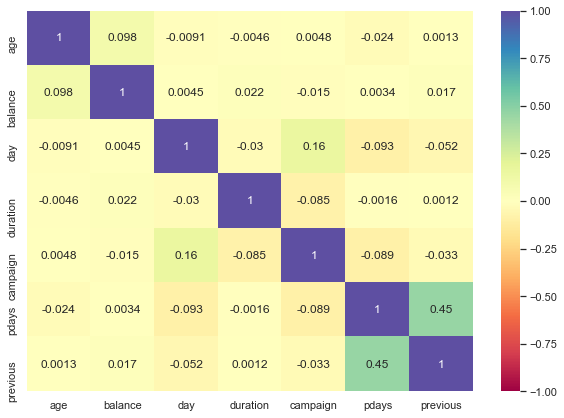

In [27]:
plt.figure(figsize=(10,7))
sns.heatmap(data.corr(), annot = True, vmin = -1, vmax= 1, fmt ='.2g', cmap = "Spectral")

In [28]:
### Function to plot stacked bar charts for categorical columns
def stacked_plot(x):
    sns.set()
    ## crosstab 
    tab1 = pd.crosstab(x,data['Target'],margins=True).sort_values(by='yes',ascending=False)
    print(tab1)
    print('-'*120)
    ## visualising the cross tab
    tab = pd.crosstab(x,data['Target'],normalize='index').sort_values(by='yes',ascending=False)
    tab.plot(kind='bar',stacked=True,figsize=(10,5))
    plt.legend(loc='lower left', frameon=False)
    plt.legend(loc="upper left", bbox_to_anchor=(1,1))
    plt.show()

Target            no   yes    All
job                              
All            39922  5289  45211
management      8157  1301   9458
technician      6757   840   7597
blue-collar     9024   708   9732
admin.          4540   631   5171
retired         1748   516   2264
services        3785   369   4154
student          669   269    938
unemployed      1101   202   1303
self-employed   1392   187   1579
entrepreneur    1364   123   1487
housemaid       1131   109   1240
unknown          254    34    288
------------------------------------------------------------------------------------------------------------------------


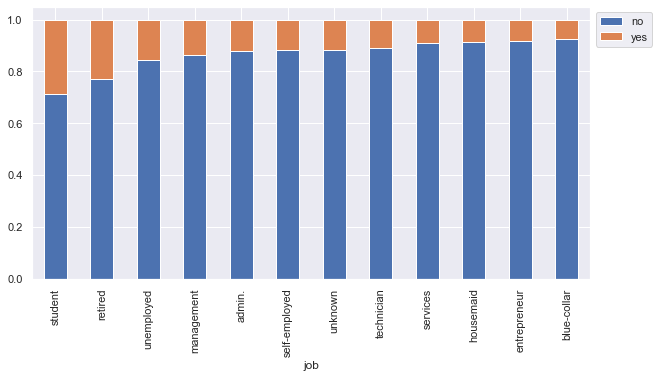

In [29]:
stacked_plot(data["job"])

We can see that students and retired customers are more likely to subscribe to the term deposit.
It is not surprising to see such a pattern because the main investment objective of older customers is saving for retirement while the middle-aged group tends to be more aggressive with the main objective of generating high investment income. Term deposits, as the least risky investment tool, are more preferable to the eldest.
The youngest may not have enough money or professional knowledge to engage in sophisticated investments, such as stocks and mutual funds. Term deposits provide liquidity and generate interest incomes that are higher than the regular saving account, so term deposits are ideal investments for students.

### Target vs marital

Target       no   yes    All
marital                     
All       39922  5289  45211
married   24459  2755  27214
single    10878  1912  12790
divorced   4585   622   5207
------------------------------------------------------------------------------------------------------------------------


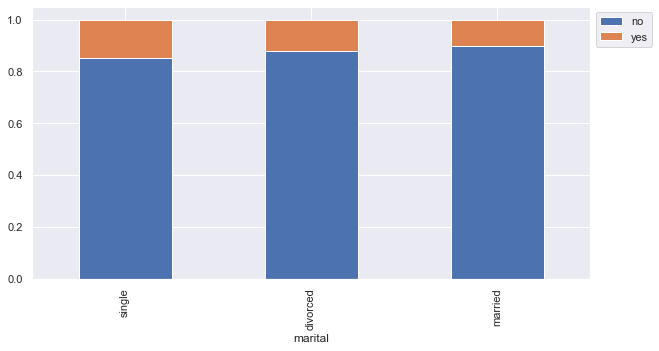

In [30]:
stacked_plot(data['marital'])

##### Single people tend to take more term deposits

### Target vs education

Target        no   yes    All
education                    
All        39922  5289  45211
secondary  20752  2450  23202
tertiary   11305  1996  13301
primary     6260   591   6851
unknown     1605   252   1857
------------------------------------------------------------------------------------------------------------------------


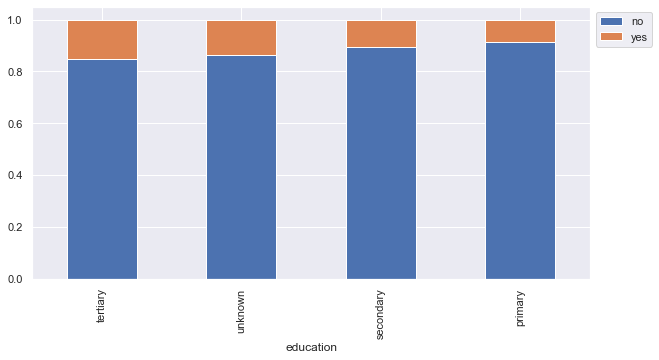

In [31]:
stacked_plot(data['education'])

#### people with higher level of education tend to subscribe more to term insurance

### Target vs housing

Target      no   yes    All
housing                    
All      39922  5289  45211
no       16727  3354  20081
yes      23195  1935  25130
------------------------------------------------------------------------------------------------------------------------


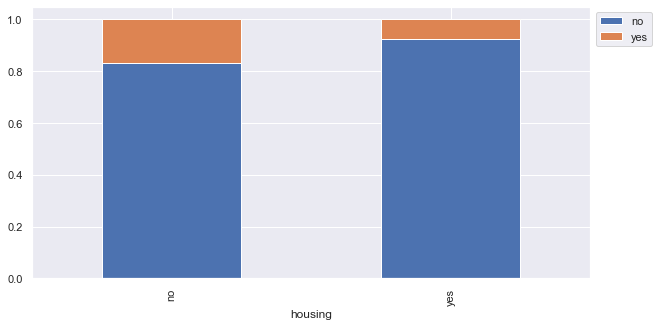

In [32]:
stacked_plot(data['housing'])

#### Customers with no housing opt for term deposits more

### Target vs Loan

Target     no   yes    All
loan                      
All     39922  5289  45211
no      33162  4805  37967
yes      6760   484   7244
------------------------------------------------------------------------------------------------------------------------


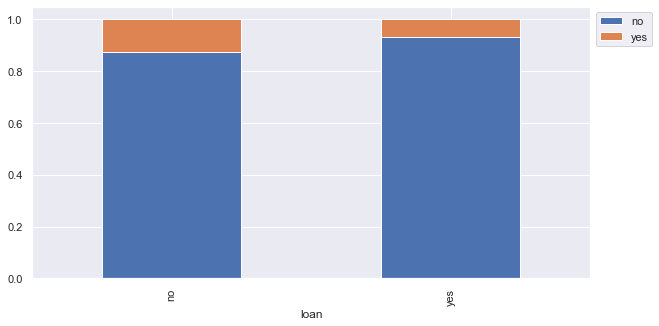

In [33]:
stacked_plot(data['loan'])

### Target vs contact

Target        no   yes    All
contact                      
All        39922  5289  45211
cellular   24916  4369  29285
unknown    12490   530  13020
telephone   2516   390   2906
------------------------------------------------------------------------------------------------------------------------


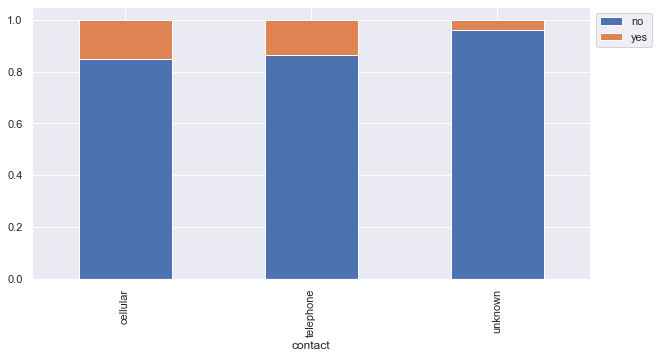

In [34]:
stacked_plot(data['contact'])

### Target vs poutcome

Target       no   yes    All
poutcome                    
All       39922  5289  45211
unknown   33573  3386  36959
success     533   978   1511
failure    4283   618   4901
other      1533   307   1840
------------------------------------------------------------------------------------------------------------------------


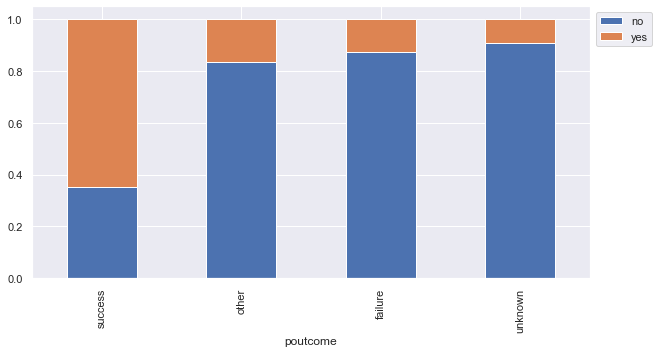

In [35]:
stacked_plot(data['poutcome'])

##### if the previous outcome was successs customer is more likely to take the loan

### Target vs month

Target     no   yes    All
month                     
All     39922  5289  45211
may     12841   925  13766
aug      5559   688   6247
jul      6268   627   6895
apr      2355   577   2932
jun      4795   546   5341
feb      2208   441   2649
nov      3567   403   3970
oct       415   323    738
sep       310   269    579
mar       229   248    477
jan      1261   142   1403
dec       114   100    214
------------------------------------------------------------------------------------------------------------------------


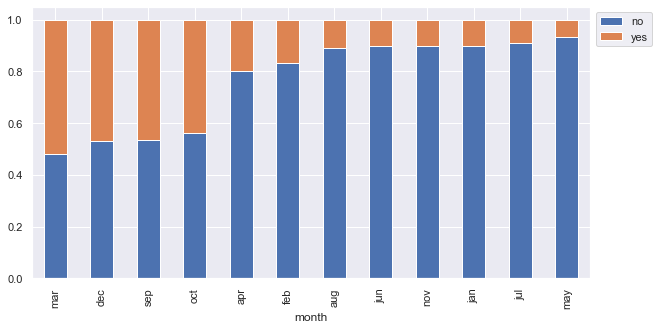

In [36]:
stacked_plot(data['month'])

##### March, sep, dec, oct were the months with most subscriptions

In [37]:
### Function to plot distributions and Boxplots of subscribers and Non-Subscribers
def plot(x,target='Target'):
    fig,axs = plt.subplots(2,2,figsize=(12,10))
    axs[0, 0].set_title('Distribution for a Non-Subscriber')
    sns.distplot(data[(data[target] == 'no')][x],ax=axs[0,0],color='teal')
    axs[0, 1].set_title('Distribution for a Subscriber')
    sns.distplot(data[(data[target] == 'yes')][x],ax=axs[0,1],color='orange')
    axs[1,0].set_title('Boxplot of Non-Subscribers and Subscribers')
    sns.boxplot(data[target],data[x],ax=axs[1,0],palette='gist_rainbow')
    axs[1,1].set_title('Boxplot of Non-Subscribers and Subscribers - Without outliers')
    sns.boxplot(data[target],data[x],ax=axs[1,1],showfliers=False,palette='gist_rainbow')
    plt.tight_layout()
    plt.show()

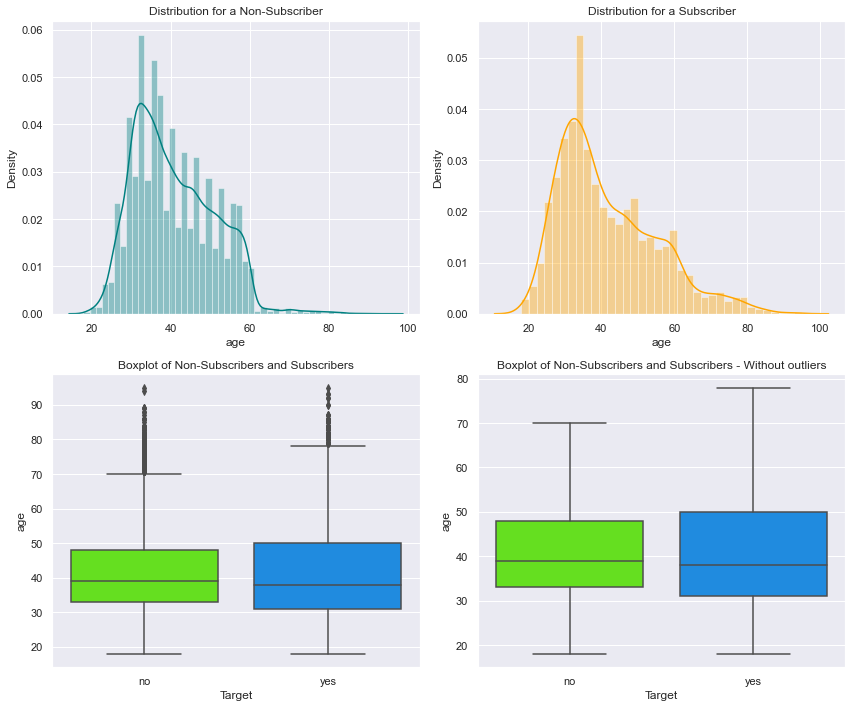

In [38]:
plot("age")

##### People above the age of 70 have subscribed to the term deposit services hence should not be considered outliers

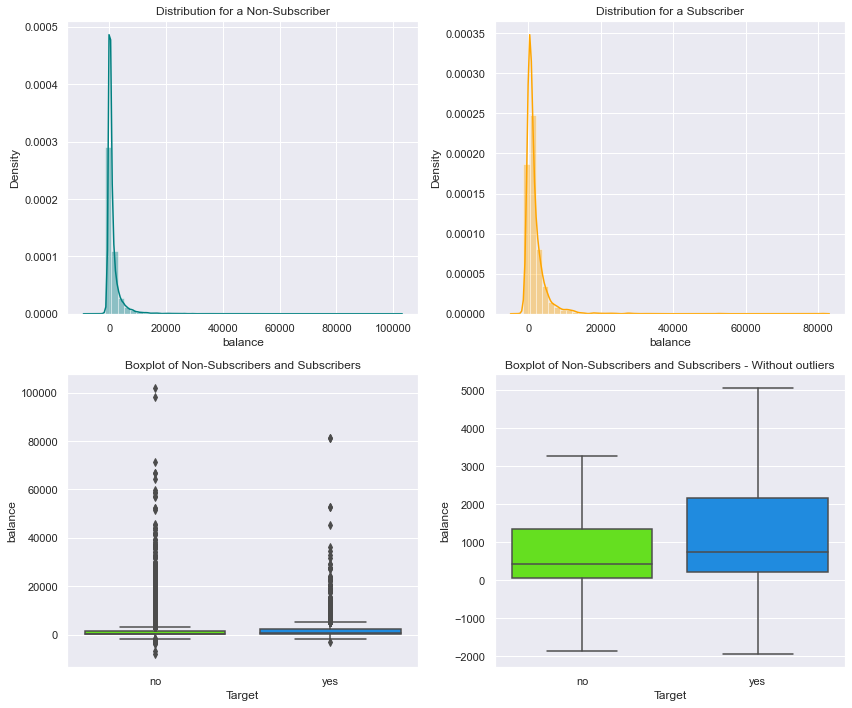

In [39]:
plot("balance")

##### The balance seems to have a right skewed distribution which is alright as balance cannot be a fixed amount considering the real world scenario,  subscribers have a smaller range of balance compared to non subscribers

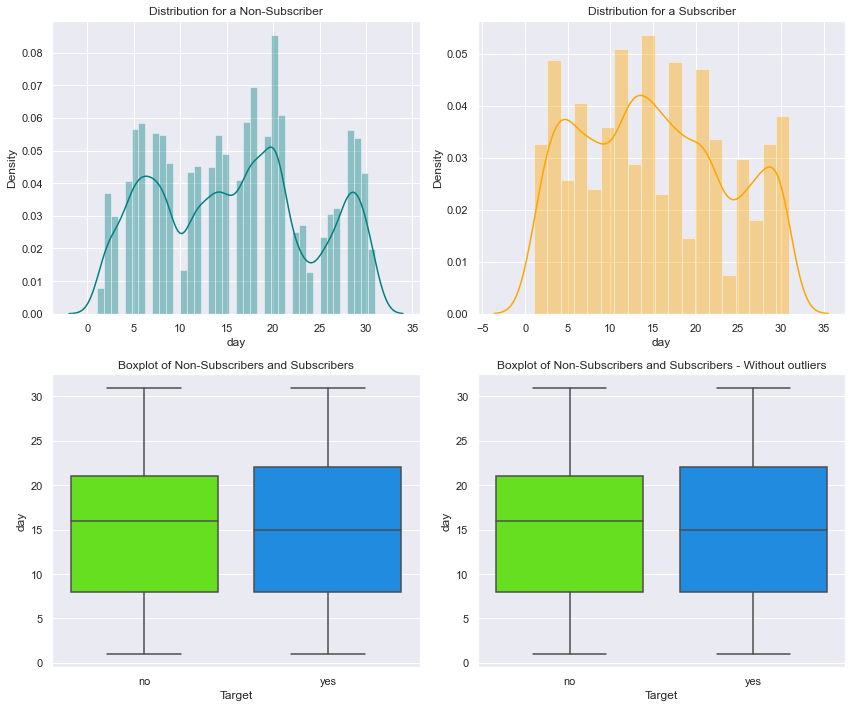

In [40]:
plot('day')

- There is no much differnece between subscribers and non subscribers

###  Target vs campaign

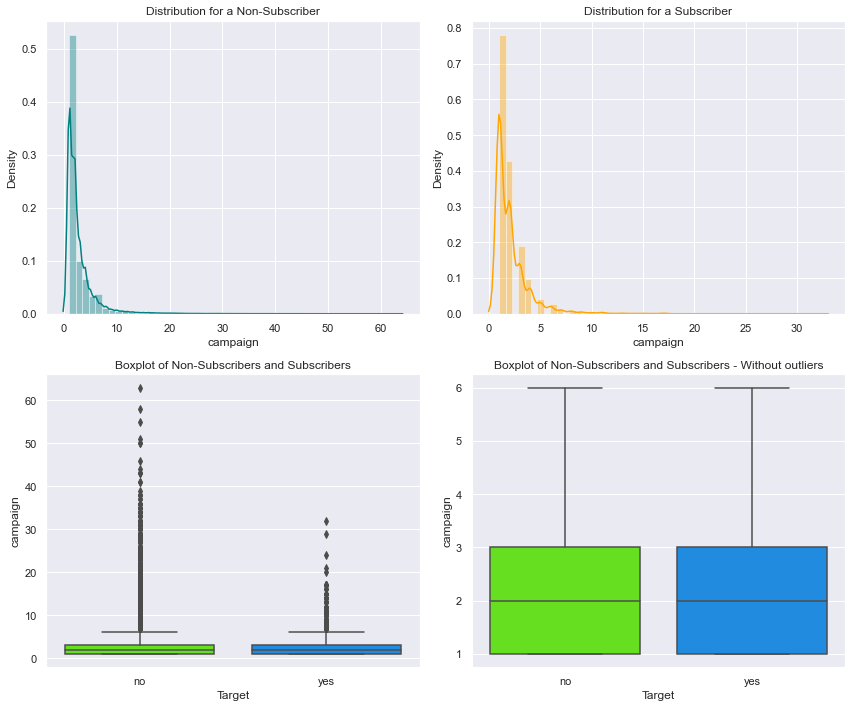

In [41]:
plot('campaign')

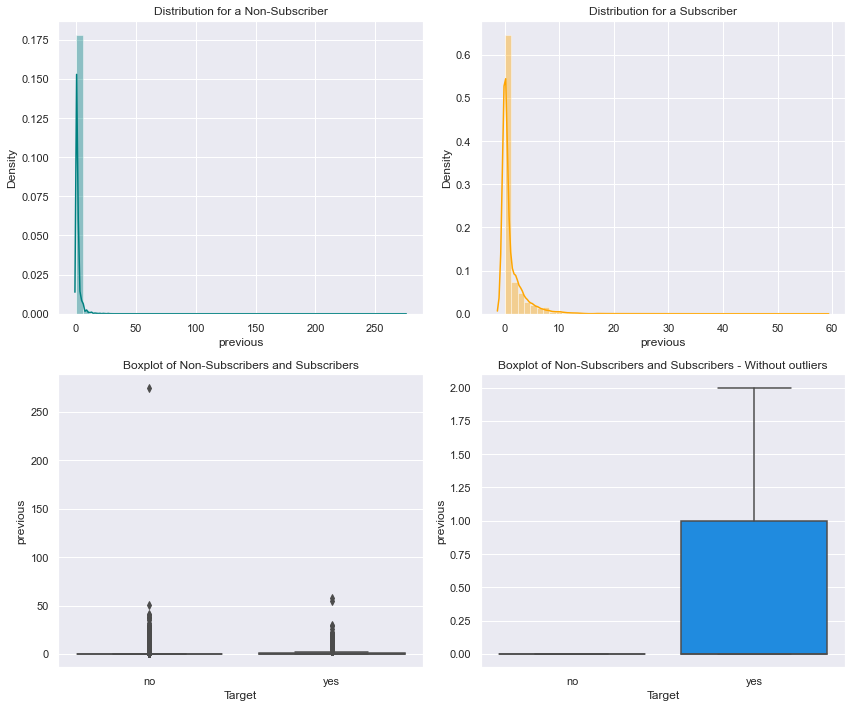

In [42]:
plot('previous')

 more the no. of times the customer was contacted , greater were the chances of subscribing

### Time to work on outliers

In [43]:
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)

IQR = q3-q1

lower = q1- 1.5*IQR
upper = q3 + 1.5*IQR

In [44]:
data.columns

Index(['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan',
       'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous',
       'poutcome', 'Target'],
      dtype='object')

In [45]:
((data[["day","age","balance","campaign", "pdays","previous"]]<lower)| (data[["day","age","balance","campaign", "pdays","previous"]]>upper)).sum()/len(data)*100

age          1.077171
balance     10.459844
campaign     6.777112
day          0.000000
duration     0.000000
pdays       18.263255
previous    18.263255
dtype: float64

We would not be treating outliers in thus case as these are real world scenarios and can be true

In [46]:
data.head()

,age,job,marital,education,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [47]:
data.drop(['duration'], axis =1 , inplace = True)

In [48]:
data['job'].replace("unknown", np.nan, inplace = True)

In [49]:
data['education'].replace("unknown", np.nan, inplace = True)

In [82]:
x = data.drop("Target", axis =1)
y = data['Target'].apply(lambda x : 1 if x=='yes' else 0)

x_train, x_test , y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=7, stratify=y)

In [83]:
x_train.shape, y_train.shape

((31647, 14), (31647,))

### MISSING VALUE TREATMENT

In [84]:
print (x_train.isnull().sum())
print ("*******"* 8)
print (x_test.isnull().sum())

age             0
job           206
marital         0
education    1288
balance         0
housing         0
loan            0
contact         0
day             0
month           0
campaign        0
pdays           0
previous        0
poutcome        0
dtype: int64
********************************************************
age            0
job           82
marital        0
education    569
balance        0
housing        0
loan           0
contact        0
day            0
month          0
campaign       0
pdays          0
previous       0
poutcome       0
dtype: int64


In [85]:
from sklearn.impute import SimpleImputer

In [86]:
si = SimpleImputer(strategy= "most_frequent")

mode_imputed_col=['job','education']

#Fit and transform the train data
x_train[mode_imputed_col]=si.fit_transform(x_train[mode_imputed_col])

#Transform the test data i.e. replace missing values with the mode calculated using training data
x_test[mode_imputed_col]=si.transform(x_test[mode_imputed_col])

In [87]:
print (x_train.isnull().sum())
print ("*******"* 8)
print (x_test.isnull().sum())

age          0
job          0
marital      0
education    0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64
********************************************************
age          0
job          0
marital      0
education    0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64


In [88]:
x_train = pd.get_dummies(x_train)
x_test = pd.get_dummies(x_test)

print (x_train.shape, x_test.shape)

(31647, 46) (13564, 46)


In [89]:
y.value_counts(1)

0    0.883015
1    0.116985
Name: Target, dtype: float64

In [90]:
y_test.value_counts(1)

0    0.882999
1    0.117001
Name: Target, dtype: float64

In [91]:
y_train.value_counts(1)

0    0.883022
1    0.116978
Name: Target, dtype: float64

### Model evaluation criterion

#### Model can make wrong predictions as:
1. Predicting a Subscribing customer as a Non-Subscriber.
2. Predicting a Non-Subscribing customer as a Subscriber.

#### Which case is more important? 
* Predicting that Subscriber as a Non-Subscriber i.e. losing on an opportunity to target a valuable customer. 

#### How to reduce this loss i.e need to reduce False Negatives?
* Bank would want Recall to be maximized, greater the Recall higher the chances of minimizing false negatives.

In [92]:
##  Function to calculate accuracy score
def get_accuracy_score(model,flag=True):
    '''
    model : classifier to predict values of X

    '''
    c = [] # defining an empty list to store train and test results
    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)
    c.append(train_acc) # adding train accuracy to list
    c.append(test_acc) # adding test accuracy to list
    if flag == True: # If the flag is set to True then only the following print statements will be dispayed
        print("Accuracy on training set : ",model.score(X_train,y_train))
        print("Accuracy on test set : ",model.score(X_test,y_test))
    
    return c # returning the list with train and test scores

In [93]:
#func to get recall score
def get_recall_score(model,flag=True):
    '''
    model : classifier to predict values of X

    '''
    a = [] # defining an empty list to store train and test results
    pred_train = model.predict(x_train)
    pred_test = model.predict(x_test)
    train_recall = metrics.recall_score(y_train,pred_train)
    test_recall = metrics.recall_score(y_test,pred_test)
    a.append(train_recall) # adding train recall to list 
    a.append(test_recall) # adding test recall to list
    if flag == True: # If the flag is set to True then only the following print statements will be dispayed
        print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
        print("Recall on test set : ",metrics.recall_score(y_test,pred_test))
    
    return a # returning the list with train and test scores

In [94]:
##  Function to calculate precision score
def get_precision_score(model,flag=True):
    '''
    model : classifier to predict values of X

    '''
    b = []  # defining an empty list to store train and test results
    pred_train = model.predict(x_train)
    pred_test = model.predict(x_test)
    train_precision = metrics.precision_score(y_train,pred_train)
    test_precision = metrics.precision_score(y_test,pred_test)
    b.append(train_precision) # adding train precision to list
    b.append(test_precision) # adding test precision to list
    if flag == True: # If the flag is set to True then only the following print statements will be dispayed
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train))
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test))

    return b # returning the list with train and test scores

In [109]:
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth  
    
    '''
    y_predict = model.predict(x_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [110]:
from sklearn import metrics

### Build Decision tree Model

- We will build a decision tree model using Gini as a default criteria
- In this case, we can pass a dictionary {0:0.11,1:0.89} to the model to specify the weight of each class and the decision tree will give more weightage to class 1. Class weight is a hyper parameter for DTC.

In [111]:
dtree = DecisionTreeClassifier(criterion="gini", random_state=1)
dtree.fit(x_train, y_train)

DecisionTreeClassifier(random_state=1)

In [112]:
confusion_matrix(y_test, dtree.predict(x_test))

array([[10793,  1184],
       [ 1045,   542]], dtype=int64)

In [113]:
print (get_accuracy_score(dtree))
print (get_recall_score(dtree))
print (get_precision_score(dtree))

Accuracy on training set :  1.0
Accuracy on test set :  0.8356679445591271
[1.0, 0.8356679445591271]
Recall on training set :  1.0
Recall on test set :  0.34152488972904854
[1.0, 0.34152488972904854]
Precision on training set :  1.0
Precision on test set :  0.31402085747392816
[1.0, 0.31402085747392816]


### Clearly decision tree is overfiitting the data and hence performing poorly on test data

- Hence resorting to hyper parameter tunning

In [104]:
dtree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_impurity_split': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 1,
 'splitter': 'best'}

In [106]:
dtree_est = DecisionTreeClassifier(random_state=1)

parameters ={
 'max_depth': np.arange(2,30),
 'max_leaf_nodes': [2,3,5,10,15],
 'min_impurity_decrease': [0.0001,0.001,0.01,0.1],'min_samples_leaf': [1, 2, 5, 7, 10],}

scorer = metrics.make_scorer(metrics.recall_score)

grid_obj = GridSearchCV(dtree_est, parameters, scoring= scorer, n_jobs=-1)
grid_obj.fit(x_train, y_train)

dtree_est = grid_obj.best_estimator_

dtree_est.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=10, max_leaf_nodes=15,
                       min_impurity_decrease=0.0001, random_state=1)

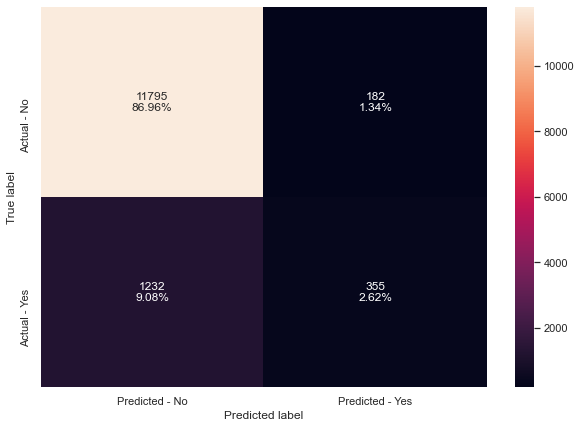

In [114]:
make_confusion_matrix(dtree_est,y_test)

In [115]:
tuned_dtree_accuracy = get_accuracy_score(dtree_est)
tuned_dtree_recall = get_recall_score(dtree_est)
tuned_dtree_accuracy = get_precision_score(dtree_est)

Accuracy on training set :  0.8937972003665434
Accuracy on test set :  0.8957534650545562
Recall on training set :  0.21150729335494328
Recall on test set :  0.2236925015752993
Precision on training set :  0.6391836734693878
Precision on test set :  0.6610800744878957


Overfitting seems to be resolved but recall on test set is really low and needs to be worked, let us try cost complexity pruning

### Bagging classifier

In [119]:
bagging = BaggingClassifier(random_state=1)
bagging.fit(x_train,y_train)

BaggingClassifier(random_state=1)

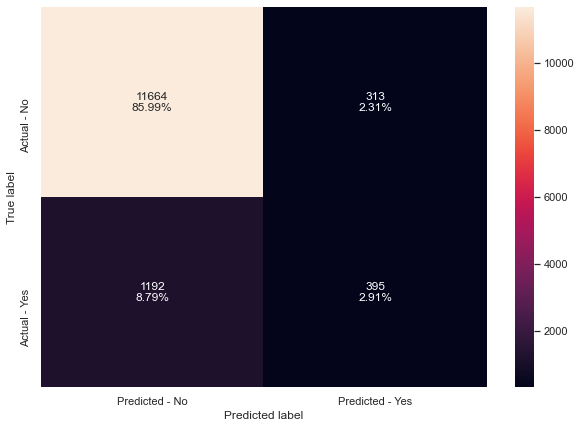

In [120]:
make_confusion_matrix(bagging, y_test)

In [121]:
bagging_acc = get_accuracy_score(bagging)
bagging_recall = get_recall_score(bagging)
bagging_precision = get_precision_score(bagging)

Accuracy on training set :  0.9849590798495907
Accuracy on test set :  0.8890445296372751
Recall on training set :  0.8787142085359265
Recall on test set :  0.24889729048519219
Precision on training set :  0.9917682926829269
Precision on test set :  0.557909604519774


* Bagging classifier is overfitting on the training set and is performing poorly on the test set in terms of recall.

In [122]:
bagging_wt = BaggingClassifier(base_estimator= DecisionTreeClassifier(class_weight={0:0.11, 1:0.89}, random_state=1), random_state=1)
bagging_wt.fit(x_train, y_train)

BaggingClassifier(base_estimator=DecisionTreeClassifier(class_weight={0: 0.11,
                                                                      1: 0.89},
                                                        random_state=1),
                  random_state=1)

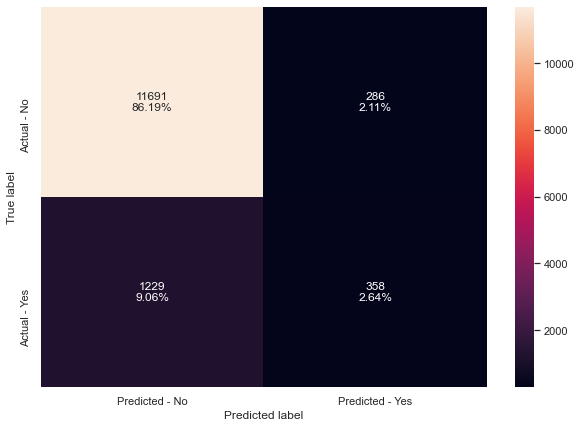

In [123]:
make_confusion_matrix(bagging_wt, y_test)

In [124]:
wt_bagging_acc = get_accuracy_score(bagging_wt)
wt_bagging_recall = get_recall_score(bagging_wt)
wt_bagging_precision = get_precision_score(bagging_wt)

Accuracy on training set :  0.9851486712800581
Accuracy on test set :  0.8883072839870245
Recall on training set :  0.8779038357644516
Recall on test set :  0.22558286074354128
Precision on training set :  0.9944920440636474
Precision on test set :  0.5559006211180124


There is not much differnce between just the bagging classifer , seems need hyper tunning

##### **Hyperparameter Tuning - Bagging Classifier**

In [125]:
# Choose the type of classifier. 
bagging_estimator_tuned = BaggingClassifier(random_state=1)

parameters = {'max_samples':[0.7,0.8,0.9,1.0],
             'max_features':[0.7,0.8,0.9,1.0],
             "n_estimators":[10,20,30,40,50]
             }
acc_score = metrics.make_scorer(metrics.recall_score)

grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring= acc_score, cv=5)
grid_obj.fit(x_train, y_train)

bagging_estimator_tuned = grid_obj.best_estimator_

bagging_estimator_tuned.fit(x_train, y_train)

BaggingClassifier(n_estimators=50, random_state=1)

In [126]:
bagg_tuned_acc = get_accuracy_score(bagging_estimator_tuned)
bagg_tuned__recall = get_recall_score(bagging_estimator_tuned)
bagg_tuned__precision = get_precision_score(bagging_estimator_tuned)

Accuracy on training set :  0.9992732328498752
Accuracy on test set :  0.8917723385432026
Recall on training set :  0.9937871420853592
Recall on test set :  0.2715816005040958
Precision on training set :  1.0
Precision on test set :  0.5800807537012113


- The result for recall has not been statisfactory so we might try other algorithms

## Random forest

In [127]:
rf = RandomForestClassifier(random_state=1)
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=1)

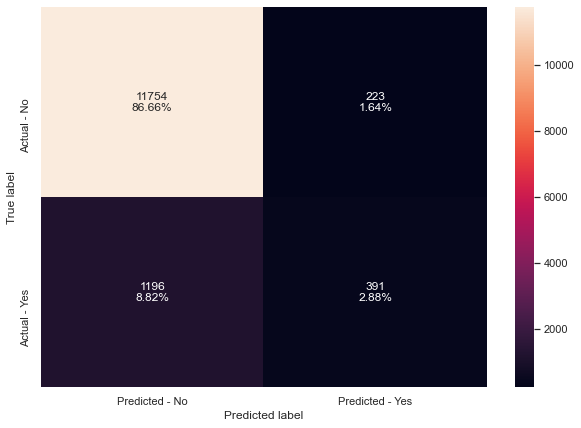

In [128]:
make_confusion_matrix(rf, y_test)

In [129]:
rf_acc = get_accuracy_score(rf)
rf_recall = get_recall_score(rf)
rf_precision = get_precision_score(rf)

Accuracy on training set :  0.9999684014282555
Accuracy on test set :  0.8953848422294308
Recall on training set :  0.9997298757428417
Recall on test set :  0.2463768115942029
Precision on training set :  1.0
Precision on test set :  0.6368078175895765


#### Random forest with class weights

In [130]:
rf_wt = RandomForestClassifier(class_weight={0:0.11, 1:0.89}, random_state=1)
rf_wt.fit(x_train, y_train)

RandomForestClassifier(class_weight={0: 0.11, 1: 0.89}, random_state=1)

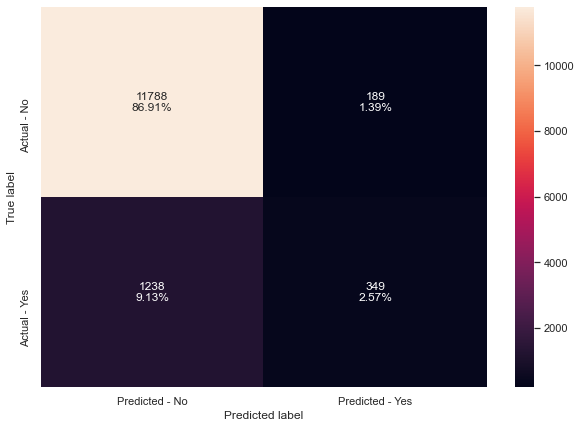

In [131]:
make_confusion_matrix(rf_wt, y_test)

In [132]:
wt_rf_acc = get_accuracy_score(rf_wt)
wt_rf_recall = get_recall_score(rf_wt)
wt_rf_precision = get_precision_score(rf_wt)

Accuracy on training set :  0.9999368028565109
Accuracy on test set :  0.8947950457092303
Recall on training set :  0.9994597514856834
Recall on test set :  0.21991178323881538
Precision on training set :  1.0
Precision on test set :  0.6486988847583643


Hyper patameter tunning for random forest

In [134]:
rf_tuned = RandomForestClassifier(random_state=1)

params = {"n_estimators":[100,150, 200,250], "min_samples_leaf":np.arange(5,10), "max_features":np.arange(0.2,0.7,1),
         "max_samples":np.arange(0.3,0.7,1)}

grid_obj = GridSearchCV(rf_tuned, param_grid= params, scoring='recall', cv=5)
grid_obj.fit(x_train, y_train)

rf_tuned = grid_obj.best_estimator_
rf_tuned.fit(x_train, y_train)

RandomForestClassifier(max_features=0.2, max_samples=0.3, min_samples_leaf=5,
                       n_estimators=200, random_state=1)

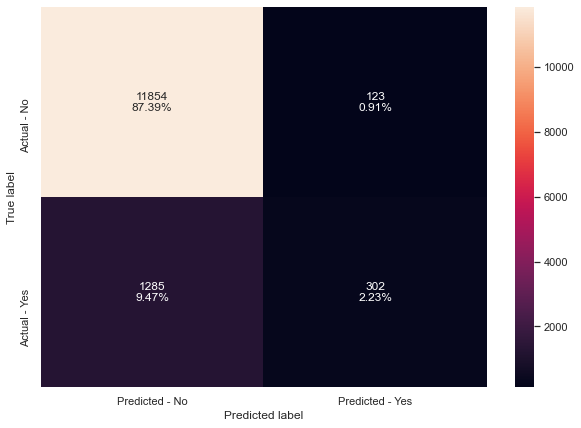

In [135]:
make_confusion_matrix(rf_tuned, y_test)

In [136]:
#Using above defined function to get accuracy on train and test set
tuned_rf_acc = get_accuracy_score(rf_tuned)
tuned_rf_recall = get_recall_score(rf_tuned)
tuned_rf_precision = get_precision_score(rf_tuned)

Accuracy on training set :  0.8985685846999716
Accuracy on test set :  0.8961958124447066
Recall on training set :  0.20016207455429497
Recall on test set :  0.19029615626969124
Precision on training set :  0.7484848484848485
Precision on test set :  0.7105882352941176


* After hyperparameter tuning the model performance has become generalized.

#### Observations:
* There is not much difference in performance of weighted and un-weighted random forest.
* After hyperparameter tuning the overfitting in Random Forest models have reduced.
* The recall is still very low.

## Adaboost classifier

In [137]:
abc = AdaBoostClassifier(random_state=1)
abc.fit(x_train, y_train)

AdaBoostClassifier(random_state=1)

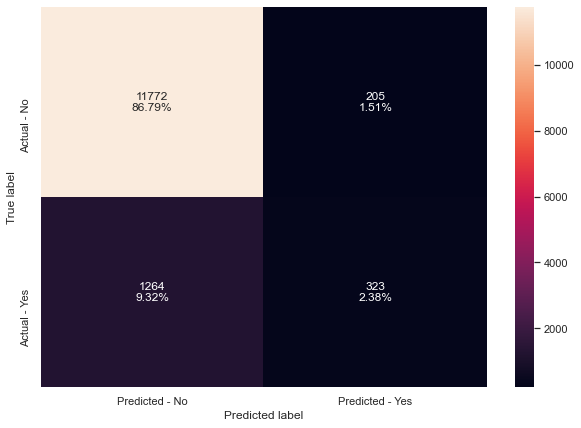

In [138]:
make_confusion_matrix(abc, y_test)

In [139]:
#Using above defined function to get accuracy on train and test set
abc_acc = get_accuracy_score(abc)
abc_recall = get_recall_score(abc)
abc_precision = get_precision_score(abc)

Accuracy on training set :  0.8914589060574462
Accuracy on test set :  0.8916986139781775
Recall on training set :  0.1917882225823879
Recall on test set :  0.203528670447385
Precision on training set :  0.6157849089332177
Precision on test set :  0.6117424242424242


In [140]:
abc.get_params()

{'algorithm': 'SAMME.R',
 'base_estimator': None,
 'learning_rate': 1.0,
 'n_estimators': 50,
 'random_state': 1}

In [144]:
abc_tuned = AdaBoostClassifier(random_state=1)

params = {"base_estimator": [DecisionTreeClassifier(max_depth=1),DecisionTreeClassifier(max_depth=2),DecisionTreeClassifier(max_depth=3)]
 ,'learning_rate': np.arange(0.1,0.7,0.1),
 'n_estimators': np.arange(25,100,25)}

grid_obj = GridSearchCV(abc_tuned,param_grid= params,scoring="recall", cv  =5)
grid_obj = grid_obj.fit(x_train, y_train)

abc_tuned = grid_obj.best_estimator_
abc_tuned.fit(x_train, y_train)


AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3),
                   learning_rate=0.6, n_estimators=75, random_state=1)

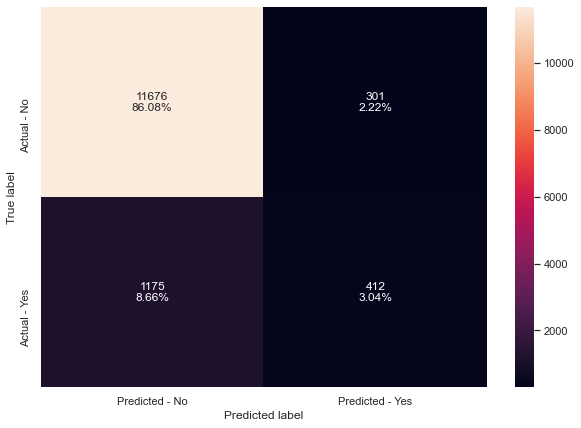

In [145]:
make_confusion_matrix(abc_tuned, y_test)

In [146]:
#Using above defined function to get accuracy on train and test set
tuned_abc_acc = get_accuracy_score(abc_tuned)
tuned_abc_recall = get_recall_score(abc_tuned)
tuned_abc_precision = get_precision_score(abc_tuned)

Accuracy on training set :  0.902960786172465
Accuracy on test set :  0.8911825420230021
Recall on training set :  0.3033495407887628
Recall on test set :  0.25960932577189666
Precision on training set :  0.6953560371517028
Precision on test set :  0.5778401122019635


### Gradient boosting classifier

In [147]:
from sklearn.ensemble import GradientBoostingClassifier

In [148]:
gbc = GradientBoostingClassifier(random_state=1)
gbc.fit(x_train, y_train)

GradientBoostingClassifier(random_state=1)

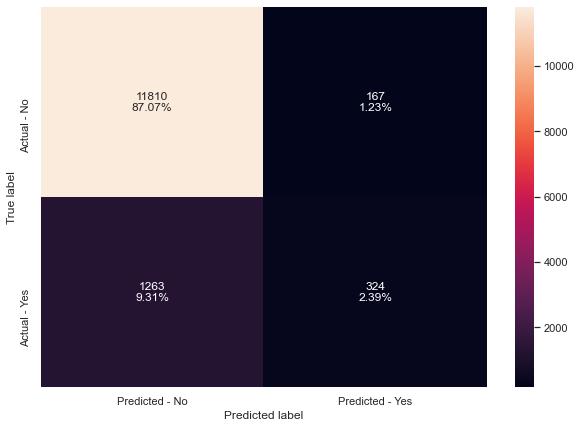

In [149]:
make_confusion_matrix(gbc, y_test)

In [150]:
#Using above defined function to get accuracy on train and test set
gbm_acc = get_accuracy_score(gbc)
gmb_recall = get_recall_score(gbc)
gbm_precision = get_precision_score(gbc)

Accuracy on training set :  0.8984421904129933
Accuracy on test set :  0.8945738720141552
Recall on training set :  0.2215018908698001
Recall on test set :  0.20415879017013233
Precision on training set :  0.7118055555555556
Precision on test set :  0.659877800407332


#### Gradient boosting with Adaboost as the base estimator

In [152]:
gbc_init = GradientBoostingClassifier(init= AdaBoostClassifier(random_state=1), random_state=1)
gbc_init.fit(x_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           random_state=1)

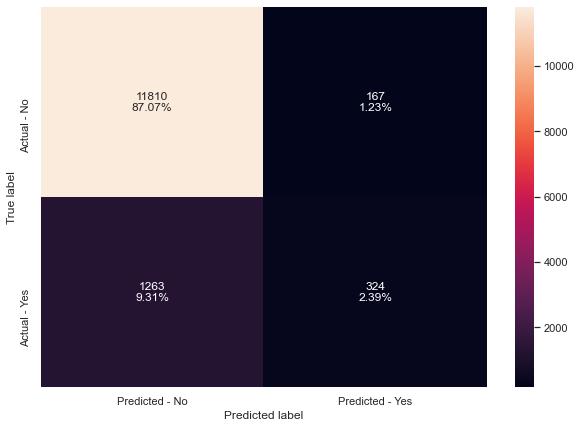

In [153]:
make_confusion_matrix(gbc, y_test)

In [154]:
#Using above defined function to get accuracy on train and test set
gbc_acc_init = get_accuracy_score(gbc_init)
gbc_recall_init = get_recall_score(gbc_init)
gbc_precision_init = get_precision_score(gbc_init)

Accuracy on training set :  0.8983789932695042
Accuracy on test set :  0.895532291359481
Recall on training set :  0.21934089681253377
Recall on test set :  0.20541902961562697
Precision on training set :  0.7135325131810193
Precision on test set :  0.6763485477178424


### Hyper parameter tuning using gbc

In [156]:
gbc_tuned = GradientBoostingClassifier(random_state=1)

params =  {'n_estimators': np.arange(75,150,25), 
              'subsample':[0.5,0.7,1],
              'max_features':[0.5,0.7,1],
              'max_depth':[1,3,5],
              'learning_rate': np.arange(0.1,1,0.2)}

grid_obj = GridSearchCV(gbc_tuned,param_grid= params, scoring= 'recall', cv =5 )
grid_obj = grid_obj.fit(x_train, y_train)

In [158]:
gbc_tuned = grid_obj.best_estimator_
gbc_tuned.fit(x_train, y_train)

GradientBoostingClassifier(learning_rate=0.7000000000000001, max_depth=5,
                           max_features=0.5, random_state=1, subsample=0.7)

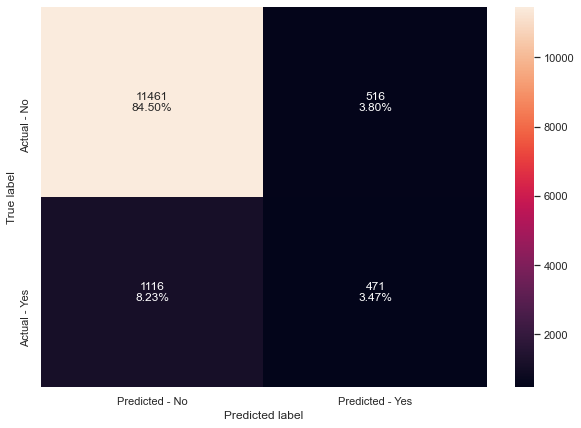

In [159]:
make_confusion_matrix(gbc_tuned, y_test)

In [161]:
gbc_tuned_acc = get_accuracy_score(gbc_tuned)
gbc_tuned_recall = get_recall_score(gbc_tuned)
gbc_tuned_precision = get_precision_score(gbc_tuned)

Accuracy on training set :  0.9336745979081745
Accuracy on test set :  0.8796815098790917
Recall on training set :  0.520259319286872
Recall on test set :  0.29678638941398866
Precision on training set :  0.8563806136060471
Precision on test set :  0.47720364741641336


We can see a bit of imporvement in the recall for test set

## XGBClassifer algortithm

In [162]:
xgb = XGBClassifier(random_state =1 , eval_metric = "logloss")
xgb.fit(x_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=4,
              num_parallel_tree=1, predictor='auto', random_state=1,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

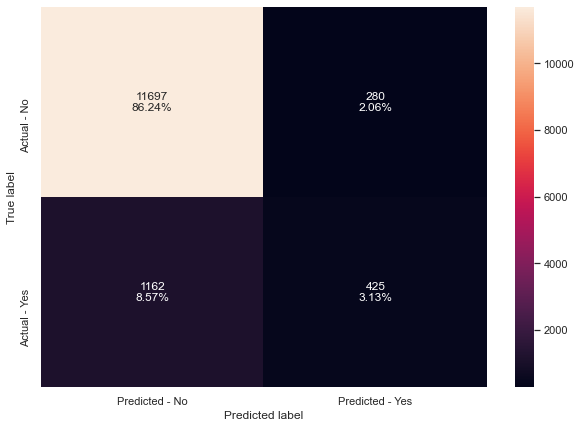

In [163]:
make_confusion_matrix(xgb, y_test)

In [164]:
xgb_acc = get_accuracy_score(xgb)
xgb_recall = get_recall_score(xgb)
xgb_precision = get_precision_score(xgb)

Accuracy on training set :  0.926438524978671
Accuracy on test set :  0.8936891772338543
Recall on training set :  0.4222042139384117
Recall on test set :  0.26780088216761183
Precision on training set :  0.8921232876712328
Precision on test set :  0.6028368794326241


xgb does not seem to perform well

### Hyperparamter tuning - XGBoost

In [169]:
xgb_tuned = XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=0.7,
              colsample_bynode=1, colsample_bytree=0.9, eval_metric='logloss',
              gamma=5, gpu_id=-1, importance_type='gain',
              interaction_constraints='', learning_rate=0.1, max_delta_step=0,
              max_depth=6, min_child_weight=1, missing=np.nan,
              monotone_constraints='()', n_estimators=100, n_jobs=8,
              num_parallel_tree=1, random_state=1, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=5, subsample=0.7, tree_method='exact',
              validate_parameters=1, verbosity=None)
xgb_tuned.fit(x_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=0.7,
              colsample_bynode=1, colsample_bytree=0.9,
              enable_categorical=False, eval_metric='logloss', gamma=5,
              gpu_id=-1, importance_type='gain', interaction_constraints='',
              learning_rate=0.1, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=8, num_parallel_tree=1, predictor='auto',
              random_state=1, reg_alpha=0, reg_lambda=1, scale_pos_weight=5,
              subsample=0.7, tree_method='exact', validate_parameters=1,
              verbosity=None)

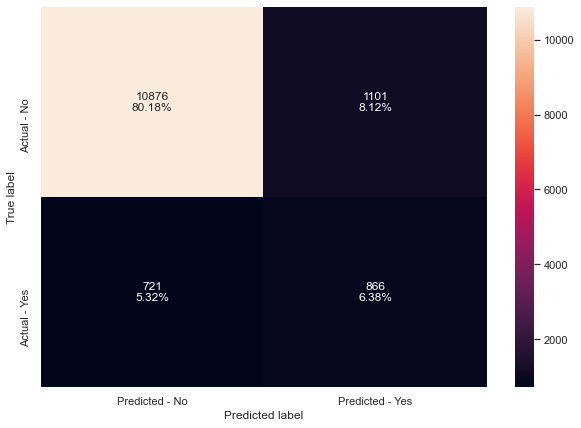

In [171]:
make_confusion_matrix(xgb_tuned, y_test)

In [172]:
xgb_tuned_acc = get_accuracy_score(xgb_tuned)
xgb_tuned_recall = get_recall_score(xgb_tuned)
xgb_tuned_precision = get_precision_score(xgb_tuned)

Accuracy on training set :  0.8802414130881284
Accuracy on test set :  0.8656738425243291
Recall on training set :  0.6134521880064829
Recall on test set :  0.5456836798991809
Precision on training set :  0.49049676025917927
Precision on test set :  0.44026436197254704


Model performance has increased significantly

### Stacking Model

- Stacking classifier stacks the output of individual estimators and use a classifier to compute the final prediction
- Stacking allows using the strength of each estimator by using their output as the input of a final estimator

In [173]:
estimators = [("Random forest", rf_tuned), ("Tuned Adaboost",abc_tuned),("Gradient boosting(init = Adaboost)", gbc_init)]

final_estimator = xgb_tuned

In [174]:
stacking_estimator = StackingClassifier(estimators= estimators, final_estimator= final_estimator, cv=5)
stacking_estimator.fit(x_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('Random forest',
                                RandomForestClassifier(max_features=0.2,
                                                       max_samples=0.3,
                                                       min_samples_leaf=5,
                                                       n_estimators=200,
                                                       random_state=1)),
                               ('Tuned Adaboost',
                                AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3),
                                                   learning_rate=0.6,
                                                   n_estimators=75,
                                                   random_state=1)),
                               ('Gradient boosting(init = Adaboost)',
                                GradientBoosting...
                                                 gpu_id=-1,
                  

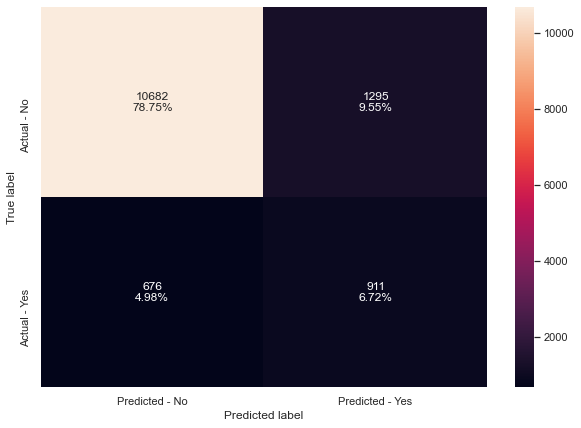

In [175]:
make_confusion_matrix(stacking_estimator, y_test)

In [176]:
stacking_acc = get_accuracy_score(stacking_estimator)
stacking_recall = get_recall_score(stacking_estimator)
stacking_precision = get_precision_score(stacking_estimator)

Accuracy on training set :  0.8618826429045408
Accuracy on test set :  0.8546888823355943
Recall on training set :  0.6115613182063749
Recall on test set :  0.5740390674228103
Precision on training set :  0.4356359438137387
Precision on test set :  0.4129646418857661


In [180]:
# defining list of models
models = [dtree,dtree_est,bagging,bagging_wt,bagging_estimator_tuned,rf,rf_wt,rf_tuned,abc,abc_tuned,gbc,gbc_init,gbc_tuned,xgb,xgb_tuned,stacking_estimator]
# defining empty lists to add train and test results
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []

# looping through all the models to get the accuracy,recall and precision scores
for model in models:
    # accuracy score
    j = get_accuracy_score(model,False)
    acc_train.append(j[0])
    acc_test.append(j[1])
    k = get_recall_score(model,False)
    recall_train.append(k[0])
    recall_test.append(k[1])
    l = get_precision_score(model,False)
    precision_train.append(l[0])
    precision_test.append(l[1])

In [182]:
comparison_frame = pd.DataFrame({'Model':['Decison Tree','Tuned Decision Tree',
                                          'Bagging classifier with default parameters','Bagging Classifier with weights',
                                          'Tuned Bagging Classifier','Random Forest with deafult parameters',
                                          'Random Forest with class_weights','Tuned Random Forest Classifier',
                                          'AdaBoost with default paramters','Tuned AdaBoost',
                                          'Gradient Boosting with default parameters',
                                          'Gradient Boosting with init=AdaBoost','Gradient Boosting Tuned',
                                          'XGBoost with default parameters','XGBoost Tuned','Stacking Classifier'], 
                                          'Train_Accuracy': acc_train,'Test_Accuracy': acc_test,
                                          'Train_Recall':recall_train,'Test_Recall':recall_test,
                                          'Train_Precision':precision_train,'Test_Precision':precision_test}) 
comparison_frame

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision
0,Decison Tree,1.000000,0.835668,1.000000,0.341525,1.000000,0.314021
1,Tuned Decision Tree,0.893797,0.895753,0.211507,0.223693,0.639184,0.661080
2,Bagging classifier with default parameters,0.984959,0.889045,0.878714,0.248897,0.991768,0.557910
3,Bagging Classifier with weights,0.985149,0.888307,0.877904,0.225583,0.994492,0.555901
4,Tuned Bagging Classifier,0.999273,0.891772,0.993787,0.271582,1.000000,0.580081
5,Random Forest with deafult parameters,0.999968,0.895385,0.999730,0.246377,1.000000,0.636808
6,Random Forest with class_weights,0.999937,0.894795,0.999460,0.219912,1.000000,0.648699
7,Tuned Random Forest Classifier,0.898569,0.896196,0.200162,0.190296,0.748485,0.710588
8,AdaBoost with default paramters,0.891459,0.891699,0.191788,0.203529,0.615785,0.611742
9,Tuned AdaBoost,0.902961,0.891183,0.303350,0.259609,0.695356,0.577840


* After tuning performance of XGBoost improved and the model gave generalized results.
* Stacking classifier has given the highest recall on the test set

## Note:
- Hyperparameter tuning is tricky and exhaustive in the sense that there is no direct way to calculate how a change in the
  hyperparameter value will reduce the loss of your model until you try those hyperparameters.
- The final results depend on the parameters used/checked using GridSearchCV.
- There may be yet better parameters that may result in better accuracy and recall. Learners can explore this further.

* Priority customers should be the ones for whom the previous campaign was a success, such customers are more likely to invest in the saving services offered by banks.

*  Housing loan is an important factor for a customer to consider the term deposits, our analysis shows that customers with no previous housing loan are more likely to subscribe for the term deposit, such customers can think of long term investments.


*  We saw that students and retired people are more likely to subscribe for the term deposit. Bank can identify this and can prioritize their strategy for these people to be better.

* Marital status, occupation, or whether they have a previous loan or not reveal a customer's life stage and indicates his/her overall risk profile. With this information, the bank can estimate when a customer can/will invest.
